# Complete hardware-agnostic quantum state tomography pipeline

This notebook is the canonical self-contained example for the `nbqs_qst` package. It generates representative two-qubit states, simulates finite-shot Pauli measurements, reconstructs a density matrix with three methods, checks physicality and quality, and repeats the complete fixed-seed MLE pipeline on NumPy and JAX.

> **AI disclosure and status:** OpenAI Codex assisted with the notebook design, code, text, and plots on 17 August 2026. The committed cells were executed locally, but independent scientific and software review remains pending. Do not label the results verified before that review.

In [1]:
import platform
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import nbqs_qst as qst

print(f"nbqs_qst {qst.__version__} | Python {platform.python_version()}")
print("Package source:", qst.__file__)
print(f"NumPy {np.__version__} | JAX {jax.__version__} | x64={jax.config.jax_enable_x64}")
print("JAX devices:", jax.devices())

nbqs_qst 0.1.0 | Python 3.13.14
Package source: C:\Users\ydkim\Desktop\nbqs_qst\package\src\nbqs_qst\__init__.py
NumPy 2.4.3 | JAX 0.11.0 | x64=True
JAX devices: [CpuDevice(id=0)]


## 1. Generate representative target states

Every generator receives a backend `like` array. The array namespace and device are inferred from that value, while all random draws come from stdlib `random.Random`. The three required state families are shown below.

In [2]:
numpy_like = np.asarray(0.0)
targets = {
    "product": qst.random_product_state(numpy_like, 2, seed=101),
    "haar": qst.random_haar_state(numpy_like, 2, seed=102),
    "mixed": qst.random_state_with_purity(
        numpy_like, 2, target_purity=0.55, seed=103
    ),
}

for name, target in targets.items():
    eigenvalues = np.linalg.eigvalsh(np.asarray(target.rho))
    print(
        f"{name:7s} shape={target.rho.shape} dtype={target.rho.dtype} "
        f"purity={target.purity:.6f} min_eigenvalue={eigenvalues[0]:+.3e}"
    )

product shape=(4, 4) dtype=complex128 purity=1.000000 min_eigenvalue=-3.914e-17
haar    shape=(4, 4) dtype=complex128 purity=1.000000 min_eigenvalue=-4.509e-17
mixed   shape=(4, 4) dtype=complex128 purity=0.550000 min_eigenvalue=+9.189e-02


## 2. Measure and reconstruct one target

Each of the $3^2=9$ X/Y/Z settings receives 512 i.i.d. single-shot draws from its exact Born distribution. The same measurement seed is reused for each reconstruction method, so LI, PLS, and MLE see identical integer counts. MLE starts from PLS to give it a physical data-dependent initial state.

In [3]:
target = targets["haar"]
runs = {}
for method in ("linear", "pls", "mle"):
    options = {"initial": "pls"} if method == "mle" else {}
    started = time.perf_counter()
    runs[method] = qst.run_tomography(
        target,
        shots=512,
        measurement_seed=201,
        method=method,
        **options,
    )
    elapsed = time.perf_counter() - started
    summary = runs[method].summary()
    fidelity = summary["fidelity"]
    fidelity_text = "not defined (nonphysical)" if fidelity is None else f"{fidelity:.8f}"
    print(
        f"{method:6s} physical={summary['physical_reconstruction']!s:5s} "
        f"converged={summary['converged']!s:5s} iterations={summary['iterations']:3d} "
        f"fidelity={fidelity_text} runtime={elapsed:.3f}s"
    )

linear physical=False converged=True  iterations=  0 fidelity=not defined (nonphysical) runtime=0.003s
pls    physical=True  converged=True  iterations=  0 fidelity=0.96999649 runtime=0.004s


mle    physical=True  converged=True  iterations= 67 fidelity=0.98074329 runtime=0.106s


In [4]:
dataset = runs["mle"].measurements
counts_are_identical = all(
    np.array_equal(left, right)
    for left, right in zip(
        runs["linear"].measurements.counts,
        runs["mle"].measurements.counts,
    )
)
assert counts_are_identical
assert dataset.settings == tuple(sorted(dataset.settings))
assert all(int(np.asarray(counts).sum()) == 512 for counts in dataset.counts)

exact = qst.pauli_expectations(target.rho)
sampled = qst.expectations_from_dataset(dataset)
print("Settings:", dataset.settings)
print("Counts per setting:", [int(np.asarray(c).sum()) for c in dataset.counts])
print("Selected exact / sampled expectations:")
for label in ("II", "XI", "IY", "ZZ"):
    print(f"  {label}: {exact[label]:+.5f} / {sampled[label]:+.5f}")

Settings: ('XX', 'XY', 'XZ', 'YX', 'YY', 'YZ', 'ZX', 'ZY', 'ZZ')
Counts per setting: [512, 512, 512, 512, 512, 512, 512, 512, 512]
Selected exact / sampled expectations:
  II: +1.00000 / +1.00000
  XI: -0.92261 / -0.90885
  IY: +0.10547 / +0.12109
  ZZ: +0.01723 / +0.01562


## 3. Inspect the estimated state and MLE convergence

The first four panels compare the target and reconstructed complex density matrices. The final panel shows the normalized multinomial negative log-likelihood after every accepted MLE step.

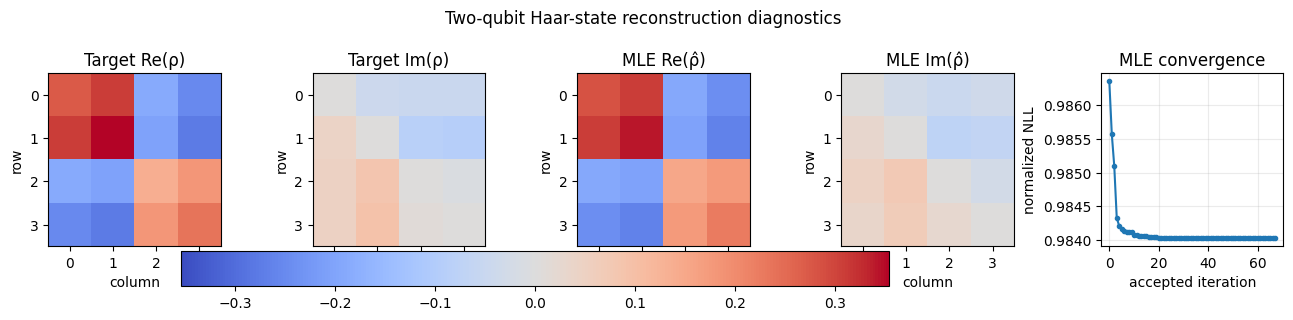

In [5]:
rho_true = np.asarray(target.rho)
rho_mle = np.asarray(runs["mle"].reconstruction.rho)
limit = max(np.max(np.abs(rho_true)), np.max(np.abs(rho_mle)))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
panels = (
    (rho_true.real, "Target Re(ρ)"),
    (rho_true.imag, "Target Im(ρ)"),
    (rho_mle.real, "MLE Re(ρ̂)"),
    (rho_mle.imag, "MLE Im(ρ̂)"),
)
for axis, (matrix, title) in zip(axes[:4], panels):
    image = axis.imshow(matrix, cmap="coolwarm", vmin=-limit, vmax=limit)
    axis.set_title(title)
    axis.set_xlabel("column")
    axis.set_ylabel("row")
fig.colorbar(image, ax=axes[:4], shrink=0.72, location="bottom")

history = runs["mle"].reconstruction.objective_history
axes[4].plot(range(len(history)), history, marker=".")
axes[4].set_title("MLE convergence")
axes[4].set_xlabel("accepted iteration")
axes[4].set_ylabel("normalized NLL")
axes[4].grid(alpha=0.25)
fig.suptitle("Two-qubit Haar-state reconstruction diagnostics")
fig.subplots_adjust(top=0.78, bottom=0.24, wspace=0.45)
plt.show()

## 4. Repeat the full pipeline on JAX

The target seed, shot count, and measurement seed are identical to the NumPy run. Exact equality of integer counts is required. Floating-point state estimates are compared at complex128 precision. This machine exposes a JAX CPU device; the result is a portability check, not a GPU benchmark.

In [6]:
jax_target = qst.random_haar_state(jnp.asarray(0.0), 2, seed=102)
jax_run = qst.run_tomography(
    jax_target,
    shots=512,
    measurement_seed=201,
    method="mle",
    initial="pls",
)

counts_match = all(
    np.array_equal(np.asarray(left), np.asarray(right))
    for left, right in zip(
        runs["mle"].measurements.counts, jax_run.measurements.counts
    )
)
target_difference = float(
    np.max(np.abs(np.asarray(target.rho) - np.asarray(jax_target.rho)))
)
mle_difference = float(
    np.max(
        np.abs(
            np.asarray(runs["mle"].reconstruction.rho)
            - np.asarray(jax_run.reconstruction.rho)
        )
    )
)
assert counts_match
assert mle_difference < 1e-10
print("Counts exactly equal:", counts_match)
print(f"Maximum target difference: {target_difference:.3e}")
print(f"Maximum MLE difference:    {mle_difference:.3e}")
print(f"NumPy/JAX fidelity: {runs['mle'].fidelity:.8f} / {jax_run.fidelity:.8f}")

Counts exactly equal: True
Maximum target difference: 5.929e-17
Maximum MLE difference:    3.357e-16
NumPy/JAX fidelity: 0.98074329 / 0.98074327


## 5. Interpretation and limitations

This example demonstrates that the same package API performs state generation, finite-shot measurement, and physical reconstruction on NumPy and JAX with fixed-seed agreement. Linear inversion is intentionally allowed to be nonphysical; the high-level pipeline therefore reports its fidelity as `None` when positivity fails. PLS and MLE enforce physical density matrices.

The example is not a large-scale benchmark. Exhaustive Pauli tomography requires $3^n$ settings and dense $2^n \times 2^n$ matrices. GPU, CuPy, PyTorch, high-qubit scaling, and publication-grade confidence intervals require separate experiments. MLE convergence diagnostics should always be inspected rather than inferred from reconstruction quality alone.

**Independent-review checklist:** verify the Born-rule convention and Y sign; review the PSD tolerance and projected-gradient optimizer; reproduce the fixed-seed outputs in a clean environment; inspect the embedded figure and backend claims; retain the AI disclosure in derived material.